<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment_9:Unsupervised Learning**

**The Problem_statement:**

the objective this assignment is apply to kmeans clustering and Hierarchical clustering to group similar flowers based on these measurements without using specified lables. the results will be evaluated to determine how well the clustering algorithms identify  natural groups in the data



**data source**: Kaggle


the data set known as The Iris dataset It includes three iris species with 50 samples each as well as some properties about each flower. One flower species is linearly separable from the other two, but the other two are not linearly separable from each other.



**The columns in this dataset are:**
Id
SepalLengthCm
SepalWidthCm
PetalLengthCm
PetalWidthCm
Species

Import all the necessary libraries for data handling, visualization, and model building

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


loading the data set

In [3]:

df = pd.read_csv("/content/drive/MyDrive/Data_set/Iris.csv")
df.head(2)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa


checking the missing value and concistency


In [4]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


the data has no missing values and in  right type of data

**Dropping columns which are neccesary for the task**

since my objective is  grouping the species
without knowing the name of species the columns with names species will be dropped and id also will be drop since it is just record of order.

In [6]:
df_clean= df.drop(columns=['Id','Species'])
df_clean.head(2)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


**Standaralization**

To have the same contribution from all features , I standardized the data because custering uses distance based methods on numerical features.

In [7]:
scaler = StandardScaler()
col = df_clean.columns
df_clean[col] = scaler.fit_transform(df_clean[col])
print(df_clean.head(3))

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      -0.900681      1.032057      -1.341272     -1.312977
1      -1.143017     -0.124958      -1.341272     -1.312977
2      -1.385353      0.337848      -1.398138     -1.312977


Elbow method

choosing the value k is important .usually k range from 5 and 10 but but has three clustering which already kirew in iris data set
so i want to make ranges from 1 to 10

<function matplotlib.pyplot.show(close=None, block=None)>

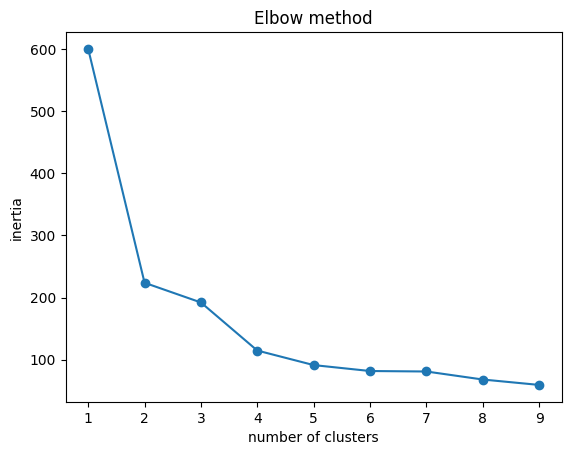

In [8]:
from sklearn.cluster import KMeans
iner_value = []
for k in range(1,10):
    n_k = KMeans(n_clusters=k, random_state=42)
    n_k.fit(df_clean)
    iner_value.append(n_k.inertia_)
plt.plot(range(1,10),iner_value,marker='o')
plt.xlabel("number of clusters")
plt.ylabel("inertia")
plt.title("Elbow method")
plt.show


the elbow happens at cluster 2, while clusters 3 and 4 are also reasonable. the biggest change in inertia happens at k 2 so k =2 is chosen. even though inertia is lower for higher k values , i will still choose k = 2 based on the elbow method.

**clustering techniques**

**K-means clustering**

In [9]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2)
kmeans

KMeans(n_clusters=2)

In [10]:
KModel = kmeans.fit(df_clean)
KModel.inertia_

223.73200573676343

**comparing the clustering vs original clustring**

when i finished my clustering  i want to compare with the original(but i reality we do not know the original value so I don't know but for this question) whether my clusterinig is good or bad.

In [11]:
pd.crosstab(df['Species'],KModel.labels_)

col_0,0,1
Species,,
Iris-setosa,0,50
Iris-versicolor,50,0
Iris-virginica,50,0


fail to cluster in good since iris-versicolor and iris virginica are considered the same

**Hierarchical clustering**


the dendrogram is built from the bottom to the top , showing how individual data points are gradually merged into larger clusters.

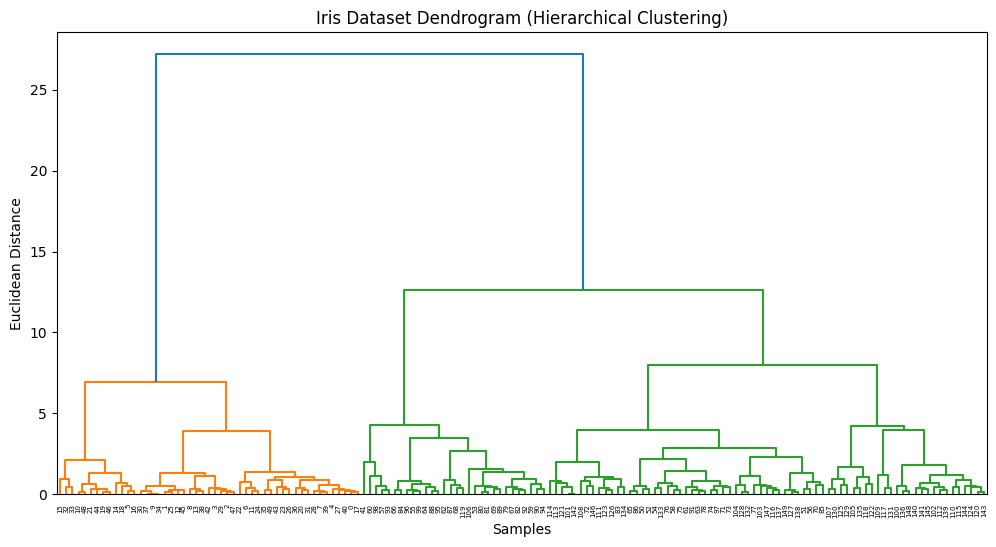

In [12]:

import scipy.cluster.hierarchy as sch
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(df_clean, method='ward'))
plt.title('Iris Dataset Dendrogram (Hierarchical Clustering)')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distance')
plt.show()

**based on Dendrogram (Hierarchical Clustering) method:**

choosing the longest vertical line(the line above the orange in above plot) and cutting horizontaly through gaps(connecting the blue line  with green block) and counting number cuts which are  three.
number cluster is 3

The Hierarchical model

In [13]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=3)
hc

AgglomerativeClustering(n_clusters=3)

In [14]:
hModel = hc.fit(df_clean)
hModel.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0,
       2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

**the comparing with original value.**

In [15]:
pd.crosstab(df['Species'],hModel.labels_)

col_0,0,1,2
Species,,,
Iris-setosa,0,49,1
Iris-versicolor,23,0,27
Iris-virginica,48,0,2


The model placed almost all Iris-setosa samples in the same cluster(only one miss placed), but Iris-versicolor and Iris-virginica overlap because of their similar characteristics

choosing right number of cluster kmeans using silhouette method

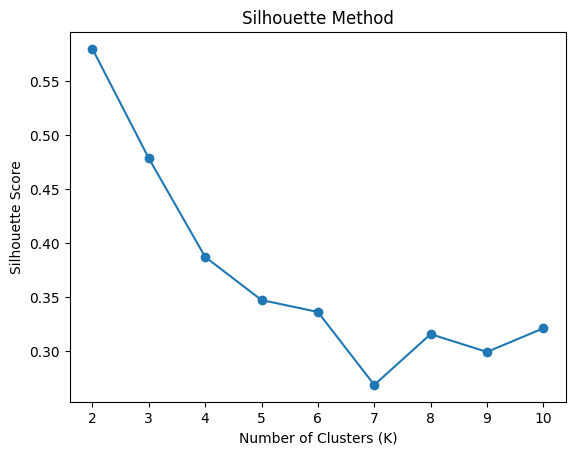

In [16]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_clean)
    scores.append(silhouette_score(df_clean, labels))

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=3)
kmeans


KMeans(n_clusters=3)

by choosing number of clusters 3 and I compare with the orginal values.

In [18]:
pd.crosstab(df['Species'],KModel.labels_)

col_0,0,1
Species,,
Iris-setosa,0,50
Iris-versicolor,50,0
Iris-virginica,50,0


all values are perfectly matched but in  reality we do not know the original value and this is  big challenge  in this assignment